# Phase 4: Model Training

Objective:
To train and evaluate machine learning models
for stock trend classification using engineered features.

This phase includes:
- Loading processed dataset
- Train-test split (chronological)
- Baseline model training
- Model evaluation

In [46]:
import pandas as pd
import numpy as np

In [47]:
df_model = pd.read_csv("../data/processed/reliance_processed.csv", index_col=0)

df_model.head()

,Close,Daily_Return,Rolling_Volatility,RSI,MACD,MACD_Signal,MACD_Hist,SMA_20,SMA_50,SMA_200,Volume_Ratio,Target
Price,,,,,,,,,,,,
2022-04-27,1264.182617,0.000973,0.017776,65.155013,31.005087,26.590278,4.414809,1208.040997,1140.257859,1096.517330,1.338175,-1
2022-04-28,1283.065796,0.014937,0.017956,67.746673,33.279303,27.928083,5.351221,1212.529694,1144.293364,1098.132168,1.674317,-1
2022-04-29,1269.597290,-0.010497,0.017841,64.085450,33.607435,29.063953,4.543482,1215.198328,1148.403940,1099.719364,1.181372,-1
2022-05-02,1265.138062,-0.003512,0.017473,62.873922,33.125806,29.876324,3.249482,1218.513086,1151.702773,1101.332950,0.621580,-1
2022-05-04,1225.643066,-0.031218,0.018997,53.268589,29.220361,29.745131,-0.524770,1219.373053,1154.257209,1102.719712,1.218453,-1


In [48]:
df_model.columns

Index(['Close', 'Daily_Return', 'Rolling_Volatility', 'RSI', 'MACD',
       'MACD_Signal', 'MACD_Hist', 'SMA_20', 'SMA_50', 'SMA_200',
       'Volume_Ratio', 'Target'],
      dtype='object')

In [49]:
# Separate features and target
X = df_model.drop("Target", axis=1)
y = df_model["Target"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (948, 11)
Target vector shape: (948,)


In [50]:
y.value_counts()

Target
 0    499
 1    233
-1    216
Name: count, dtype: int64

In [51]:
# 80% training, 20% testing
split_index = int(len(df_model) * 0.8)

split_index

758

In [52]:
X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 758
Testing samples: 190


In [53]:
print("Last training date:", df_model.index[split_index - 1])
print("First testing date:", df_model.index[split_index])

Last training date: 2025-05-22
First testing date: 2025-05-23


In [54]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [55]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [56]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [57]:
y_pred = rf_model.predict(X_test)

In [58]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.4368421052631579

Classification Report:

              precision    recall  f1-score   support

          -1       0.29      0.49      0.36        37
           0       0.59      0.48      0.53       115
           1       0.29      0.26      0.28        38

    accuracy                           0.44       190
   macro avg       0.39      0.41      0.39       190
weighted avg       0.47      0.44      0.45       190



In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

In [60]:
cm = confusion_matrix(y_test, y_pred)

cm

array([[18, 19,  0],
       [36, 55, 24],
       [ 9, 19, 10]])

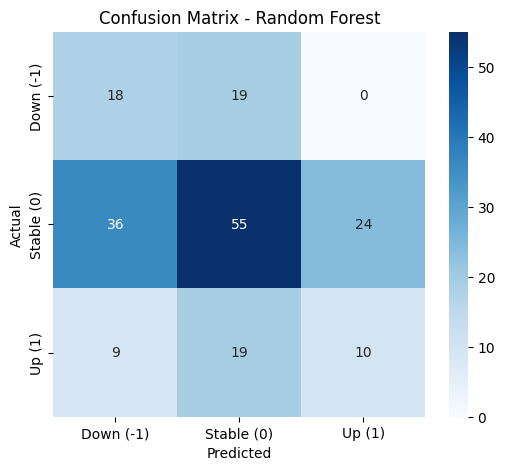

In [61]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Down (-1)", "Stable (0)", "Up (1)"],
    yticklabels=["Down (-1)", "Stable (0)", "Up (1)"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [62]:
# Get feature importances
importances = rf_model.feature_importances_

# Create dataframe
feature_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)

feature_importance_df

,Feature,Importance
9,SMA_200,0.132065
7,SMA_20,0.101725
8,SMA_50,0.097295
2,Rolling_Volatility,0.096615
0,Close,0.094851
5,MACD_Signal,0.089611
6,MACD_Hist,0.088308
4,MACD,0.084080
3,RSI,0.083088
10,Volume_Ratio,0.066692


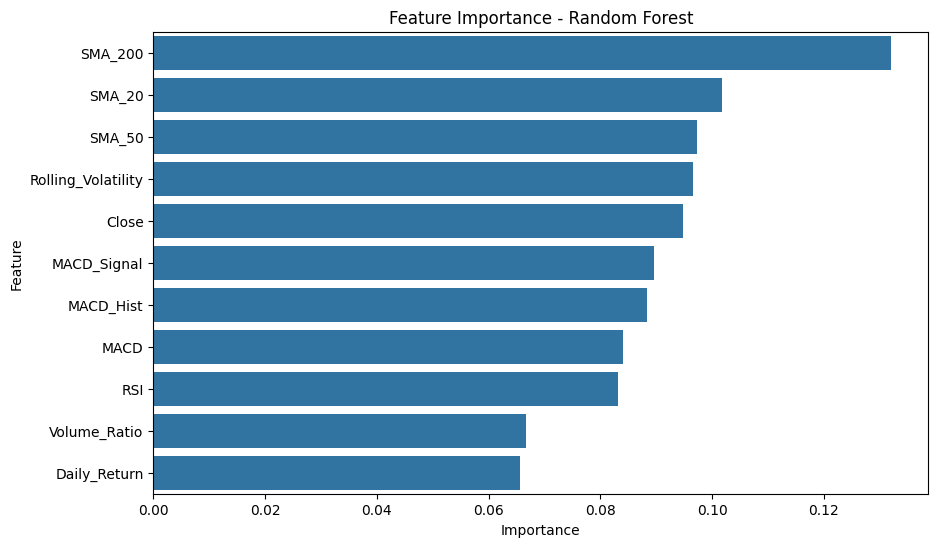

In [63]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance_df
)

plt.title("Feature Importance - Random Forest")
plt.show()

In [64]:
from xgboost import XGBClassifier

In [65]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    objective="multi:softmax",
    num_class=3,
    random_state=42
)

In [66]:
# Map original labels to XGBoost-compatible labels
label_mapping = {
    -1: 0,   # Down
     0: 1,   # Stable
     1: 2    # Up
}

y_train_encoded = y_train.map(label_mapping)
y_test_encoded = y_test.map(label_mapping)

y_train_encoded.value_counts()

Target
1    384
2    195
0    179
Name: count, dtype: int64

In [67]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    objective="multi:softprob",  # Better than softmax
    num_class=3,
    random_state=42,
    eval_metric="mlogloss"
)

In [68]:
xgb_model.fit(X_train, y_train_encoded)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [69]:
y_pred_xgb_encoded = xgb_model.predict(X_test)

In [70]:
reverse_mapping = {0: -1, 1: 0, 2: 1}

y_pred_xgb = pd.Series(y_pred_xgb_encoded).map(reverse_mapping)

In [71]:
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.4105263157894737

Classification Report:

              precision    recall  f1-score   support

          -1       0.25      0.38      0.30        37
           0       0.55      0.42      0.47       115
           1       0.35      0.42      0.38        38

    accuracy                           0.41       190
   macro avg       0.38      0.41      0.38       190
weighted avg       0.45      0.41      0.42       190



In [72]:
rf_accuracy = accuracy_score(y_test, y_pred)
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)

print("Random Forest Accuracy:", rf_accuracy)
print("XGBoost Accuracy:", xgb_accuracy)

Random Forest Accuracy: 0.4368421052631579
XGBoost Accuracy: 0.4105263157894737


In [73]:
from sklearn.metrics import f1_score

rf_f1 = f1_score(y_test, y_pred, average="weighted")
xgb_f1 = f1_score(y_test, y_pred_xgb, average="weighted")

print("Random Forest F1 Score:", rf_f1)
print("XGBoost F1 Score:", xgb_f1)

Random Forest F1 Score: 0.44575191183085927
XGBoost F1 Score: 0.4210537467138368


In [74]:
comparison_df = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Accuracy": [rf_accuracy, xgb_accuracy],
    "F1 Score (Weighted)": [rf_f1, xgb_f1]
})

comparison_df

,Model,Accuracy,F1 Score (Weighted)
0,Random Forest,0.436842,0.445752
1,XGBoost,0.410526,0.421054


In [75]:
# Get feature importance from XGBoost
xgb_importances = xgb_model.feature_importances_

# Create dataframe
xgb_feature_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_importances
})

# Sort by importance
xgb_feature_importance_df = xgb_feature_importance_df.sort_values(
    by="Importance", ascending=False
)

xgb_feature_importance_df

,Feature,Importance
9,SMA_200,0.135851
8,SMA_50,0.124373
7,SMA_20,0.112732
4,MACD,0.106589
0,Close,0.092497
6,MACD_Hist,0.088752
2,Rolling_Volatility,0.083351
5,MACD_Signal,0.073991
3,RSI,0.070801
10,Volume_Ratio,0.067058


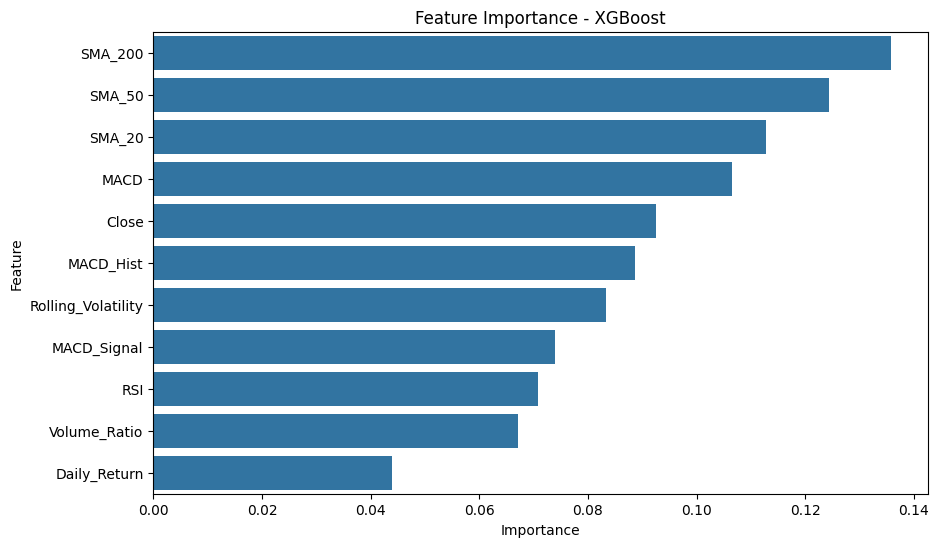

In [76]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=xgb_feature_importance_df
)

plt.title("Feature Importance - XGBoost")
plt.show()

In [77]:
import shap


In [78]:
explainer = shap.TreeExplainer(xgb_model)

In [79]:
shap_values = explainer.shap_values(X_test)

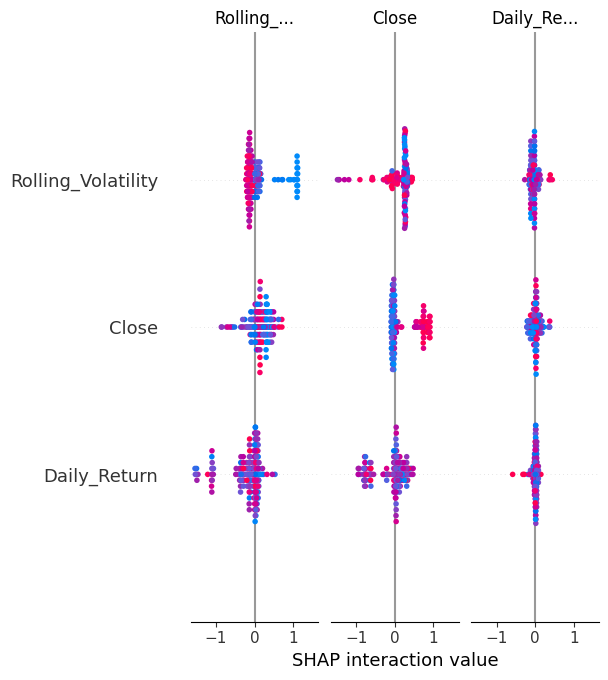

In [80]:
shap.summary_plot(shap_values, X_test)

In [81]:
# Select one test instance (for example, the first one)
sample_index = 0

sample = X_test.iloc[sample_index:sample_index+1]

sample

,Close,Daily_Return,Rolling_Volatility,RSI,MACD,MACD_Signal,MACD_Hist,SMA_20,SMA_50,SMA_200,Volume_Ratio
Price,,,,,,,,,,,
2025-05-23,1421.124268,0.012346,0.018866,60.061619,34.729768,40.188389,-5.458621,1407.085248,1311.369517,1323.3335,0.453382


In [82]:
sample_shap_values = explainer.shap_values(sample)

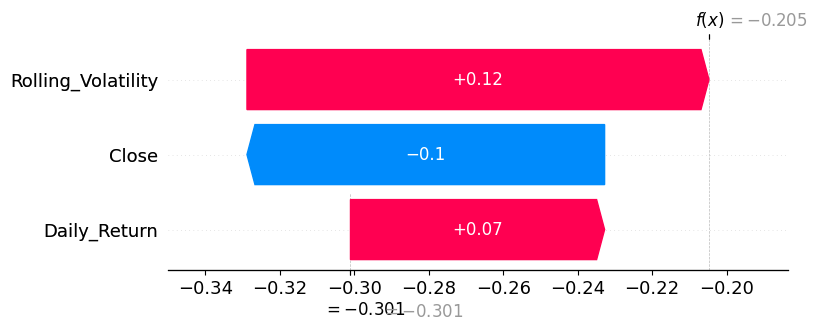

In [83]:
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value[0],  # class 0 baseline
    sample_shap_values[0][0],     # SHAP values for sample
    feature_names=X_test.columns
)

In [84]:
# Recompute daily returns (safe)
df_full = pd.read_csv("../data/processed/reliance_processed.csv", index_col=0)

# Annualized Volatility
daily_std = df_full["Daily_Return"].std()
annual_volatility = daily_std * (252 ** 0.5)

print("Annualized Volatility:", annual_volatility)

Annualized Volatility: 0.21244521150063064


# There are approximately 252 trading days per year.



In [85]:
# Mean daily return
mean_daily_return = df_full["Daily_Return"].mean()

# Annualized mean return
annual_return = mean_daily_return * 252

# Sharpe Ratio
sharpe_ratio = annual_return / annual_volatility

print("Annualized Return:", annual_return)
print("Sharpe Ratio:", sharpe_ratio)

Annualized Return: 0.05518499323329256
Sharpe Ratio: 0.25976105953853773


In [86]:
# Normalize volatility (higher = riskier)
vol_score = min(annual_volatility * 100, 100)

# Normalize Sharpe (higher = safer, invert effect)
sharpe_score = max(0, (1 - sharpe_ratio) * 50)

# Composite Risk Score
risk_score = (vol_score * 0.6) + (sharpe_score * 0.4)

print("Composite Risk Score:", risk_score)

Composite Risk Score: 27.551491499267087


In [87]:
if risk_score < 33:
    risk_category = "Low Risk"
elif risk_score < 66:
    risk_category = "Medium Risk"
else:
    risk_category = "High Risk"

print("Risk Category:", risk_category)

Risk Category: Low Risk


# Build Buy / Hold / Sell Recommendation Engine

We combine:

Predicted Trend

Model Confidence

Risk Category

In [88]:
# Get probability predictions
y_prob = xgb_model.predict_proba(X_test)

# Take first test sample
sample_index = 0

sample_probs = y_prob[sample_index]

sample_probs

array([0.05812078, 0.76035994, 0.18151924], dtype=float32)

In [89]:
predicted_encoded = y_pred_xgb_encoded[sample_index]

# Convert back to original label
reverse_mapping = {0: -1, 1: 0, 2: 1}
predicted_label = reverse_mapping[predicted_encoded]

print("Predicted Trend:", predicted_label)

Predicted Trend: 0


In [90]:
confidence = max(sample_probs)

print("Prediction Confidence:", confidence)

Prediction Confidence: 0.76035994


In [91]:
# Example decision rules

if predicted_label == 1 and risk_category == "Low Risk":
    recommendation = "Strong Buy"
    
elif predicted_label == 1 and risk_category == "Medium Risk":
    recommendation = "Buy"
    
elif predicted_label == 1 and risk_category == "High Risk":
    recommendation = "Hold (High Risk)"
    
elif predicted_label == 0:
    recommendation = "Hold"
    
elif predicted_label == -1:
    recommendation = "Sell"
    
print("Final Recommendation:", recommendation)

Final Recommendation: Hold


In [1]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

In [4]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

In [5]:
df_model = pd.read_csv("../data/processed/reliance_processed.csv", index_col=0)

In [6]:
X = df_model.drop("Target", axis=1)
y = df_model["Target"]

In [7]:
label_mapping = {-1: 0, 0: 1, 1: 2}
y_encoded = y.map(label_mapping)

In [8]:
split_index = int(len(df_model) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train_encoded = y_encoded[:split_index]
y_test_encoded = y_encoded[split_index:]

In [9]:
tscv = TimeSeriesSplit(n_splits=5)

In [10]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200]
}

grid_search = GridSearchCV(
    XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        random_state=42
    ),
    param_grid,
    cv=tscv,
    scoring="f1_weighted",
    verbose=1
)

grid_search.fit(X_train, y_train_encoded)

best_model = grid_search.best_estimator_
best_model

Fitting 5 folds for each of 18 candidates, totalling 90 fits


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [12]:
from sklearn.metrics import accuracy_score, classification_report, f1_score

In [13]:
y_pred_tuned = best_model.predict(X_test)

print("Tuned Model Accuracy:", accuracy_score(y_test_encoded, y_pred_tuned))
print("\nClassification Report:\n")
print(classification_report(y_test_encoded, y_pred_tuned))

Tuned Model Accuracy: 0.6105263157894737

Classification Report:

              precision    recall  f1-score   support

           0       0.60      0.08      0.14        37
           1       0.61      0.98      0.75       115
           2       0.00      0.00      0.00        38

    accuracy                           0.61       190
   macro avg       0.40      0.35      0.30       190
weighted avg       0.49      0.61      0.48       190



c:\Users\Dell\ai-stock-advisor\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Dell\ai-stock-advisor\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Dell\ai-stock-advisor\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

In [14]:
# All imports in one place
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import accuracy_score, classification_report, f1_score

In [15]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_encoded),
    y=y_train_encoded
)

class_weights

array([1.41154562, 0.65798611, 1.2957265 ])